In [42]:

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.model_selection import train_test_split
from concurrent.futures import ProcessPoolExecutor

from rdkit import Chem
from mordred import Calculator, descriptors
from mordred import (HydrogenBond, TopoPSA, SLogP, RotatableBond,
                     Weight, VdwVolumeABC, Constitutional, Polarizability, CPSA)

from botorch.exceptions.warnings import BadInitialCandidatesWarning
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement as ExpectedImprovement
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize

from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel, ProductKernel
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.distributions import MultivariateNormal

from gauche.dataloader import MolPropLoader
from gauche.kernels.fingerprint_kernels.tanimoto_kernel import TanimotoKernel

# Experiment parameters
N_TRIALS = 20
holdout_set_size = 0.95
N_ITERS = 20
verbose = True


class TanimotoGP(SingleTaskGP):
    def __init__(self, train_X, train_Y, d_fingerprint=2048):
        super().__init__(train_X, train_Y, likelihood=GaussianLikelihood(), 
                         input_transform=Normalize(d=train_X.shape[1]),
                         outcome_transform=Standardize(m=train_Y.shape[1]))
        self.mean_module = ConstantMean()
        tanimoto_kernel = TanimotoKernel(active_dims=list(range(d_fingerprint)))
        rbf_kernel = RBFKernel(active_dims=[d_fingerprint])
        self.covar_module = ScaleKernel(ProductKernel(tanimoto_kernel, rbf_kernel))
        self.to(train_X)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

def initialize_model_tanimoto_gp(train_x, train_y, state_dict=None):
    model = TanimotoGP(train_x, train_y).to(train_x)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    if state_dict:
        model.load_state_dict(state_dict)
    return mll, model

def initialize_model_se_gp(train_x, train_y, state_dict=None):
    model = SingleTaskGP(
        train_X=train_x, 
        train_Y=train_y,
        input_transform=Normalize(d=train_x.shape[1]),
        outcome_transform=Standardize(m=train_y.shape[1])
    ).to(train_x)
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    if state_dict:
        model.load_state_dict(state_dict)
    return mll, model

def optimize_acqf_and_get_observation(acq_func, heldout_x, heldout_y):
    acq_vals = torch.tensor([acq_func(x.unsqueeze(0)) for x in heldout_x])
    best_idx = torch.argmax(acq_vals)
    new_x = heldout_x[best_idx].unsqueeze(0)
    new_y = heldout_y[best_idx].unsqueeze(0)
    heldout_x = torch.cat([heldout_x[:best_idx], heldout_x[best_idx+1:]])
    heldout_y = torch.cat([heldout_y[:best_idx], heldout_y[best_idx+1:]])
    return new_x, new_y, heldout_x, heldout_y


def expert_featurization(smiles_list, return_df=False):

    calc = Calculator([
        HydrogenBond.HBondAcceptor,
        # HydrogenBond.HBondDonor,
        TopoPSA.TopoPSA,
        SLogP.SLogP,
        # RotatableBond.RotatableBondsCount,
        Weight,
        # VdwVolumeABC,
        # Constitutional,
        # Polarizability,
        CPSA,
    ])

    # calc = Calculator(descriptors.all, ignore_3D=False)

    # Convert SMILES to RDKit Mol objects, skipping invalids
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    valid_idx = [i for i, mol in enumerate(mols) if mol is not None]
    valid_mols = [mols[i] for i in valid_idx]
    
    # Compute descriptors
    X_calc = calc.pandas(valid_mols, nproc=1)

    # Fill missing values with 0 or another strategy
    X_calc = X_calc.fillna(0)
    X_calc = X_calc.select_dtypes(include=[np.number])  # Ensure only numeric columns are kept
    print(f"Expert featurization dims: {X_calc.shape}")
    if return_df:
        return X_calc
    return X_calc.to_numpy()




In [43]:


# Load the Lactate Solubility dataset
loader = MolPropLoader()
loader.read_csv(path="./output_data_full.csv", smiles_column="SMILES", label_column="KV")
df = pd.read_csv("./output_data_full.csv")

#change
solvents_id_solvent_dict = {v:k for k, v in enumerate(df["SMILES"].unique())}

df["solvent_id"] = df["SMILES"].map(solvents_id_solvent_dict)

# Featurize using fragprints representations

loader.featurize('ecfp_fragprints')
y = loader.labels
X_temp = df["Temperature (°C)"]

X_fp = loader.features
X_fp = np.concatenate((X_fp, X_temp.values.reshape(-1, 1)), axis=1)  # Add temperature as a feature
X_alphab = np.concatenate((df["solvent_id"].values.reshape(-1, 1), X_temp.values.reshape(-1, 1)), axis=1)
X_expert = expert_featurization(df["SMILES"])
df_expert = expert_featurization(df["SMILES"], return_df=True)

X_expert_df = df_expert.copy().select_dtypes(include=[np.number])

# run_trial(1)




100%|██████████| 1440/1440 [00:01<00:00, 1133.84it/s]


Expert featurization dims: (1440, 8)


100%|██████████| 1440/1440 [00:01<00:00, 1070.77it/s]

Expert featurization dims: (1440, 8)


In [44]:

loader = MolPropLoader()
loader.read_csv(path="./output_data_full.csv", smiles_column="SMILES", label_column="KV")
df = pd.read_csv("./output_data_full.csv")

#change
solvents_id_solvent_dict = {v:k for k, v in enumerate(df["SMILES"].unique())}

df["solvent_id"] = df["SMILES"].map(solvents_id_solvent_dict)

index_b = (df["Temperature (°C)"] == 30.0) & (df["Phase 1 x(1) input"] > 0.998)

# Featurize using fragprints representations

loader.featurize('ecfp_fragprints')
y = loader.labels

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
df_expert["y"] = y
df_expert["SMILES"] = df["SMILES"]

#horz cat full df to df_expert 
df_expert2 = df_expert[index_b].copy()

<Figure size 1000x800 with 0 Axes>

In [46]:
import torch
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", deterministic_eval=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

smiles = df_expert2["SMILES"].tolist()
inputs = tokenizer(smiles, padding=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
outputs.pooler_output.shape  # (batch_size, hidden_size)

df_expert2["embeddings"] = outputs.pooler_output.numpy().tolist()

Text(0, 0.5, 'UMAP Component 2')

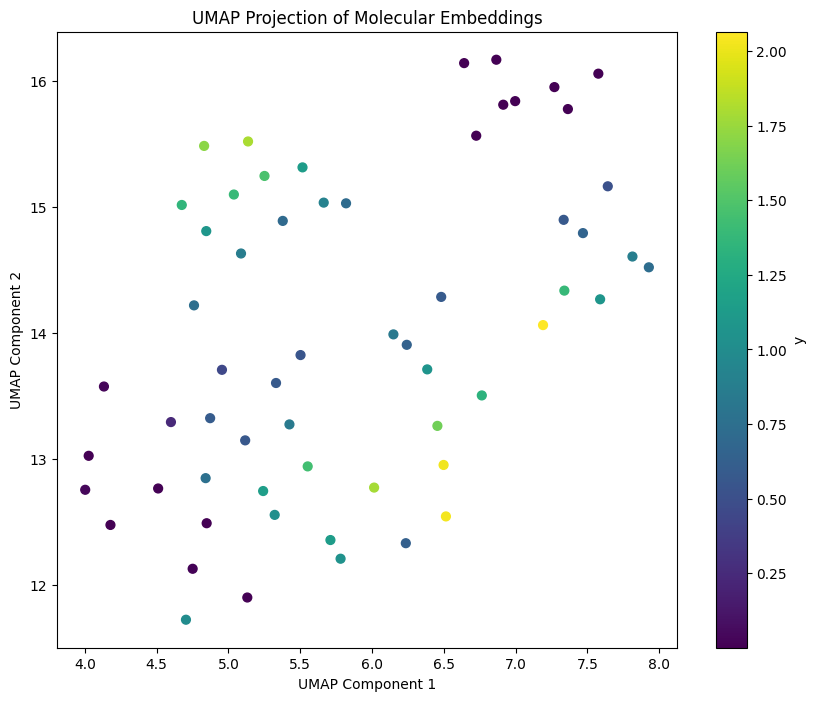

In [47]:
import umap
import matplotlib.pyplot as plt
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=40)
embedding = reducer.fit_transform(np.array(df_expert2["embeddings"].tolist()))
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df_expert2["y"], cmap='viridis', s=40) 
plt.colorbar(label='y')
plt.title('UMAP Projection of Molecular Embeddings')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

Root mean squared test error = 0.21043578916091574
R2 test score = 0.8429136654026065


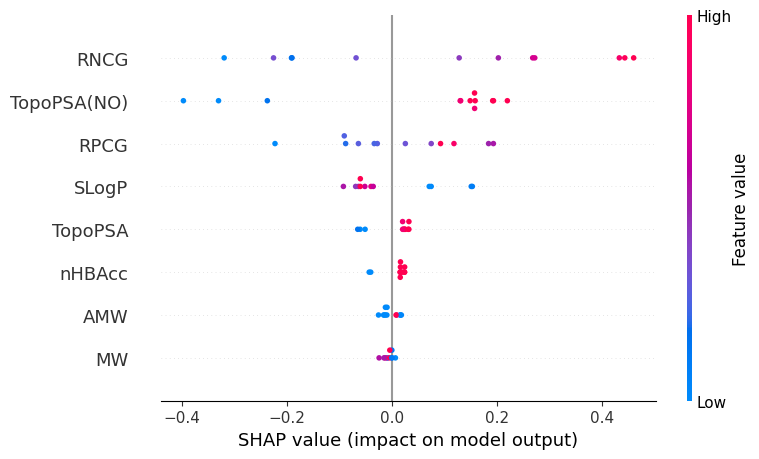

In [57]:
import time

import numpy as np
from sklearn.model_selection import train_test_split

# pca
from sklearn.decomposition import PCA

#r2
from sklearn.metrics import r2_score

import shap

X_expert_df = df_expert2.copy().drop(columns=["y", "SMILES", "embeddings"])
y = df_expert2["y"].values

X_train, X_test, y_train, y_test = train_test_split(X_expert_df, y, test_size=0.2, random_state=0)

# rather than use the whole training set to estimate expected values, we summarize with
# a set of weighted kmeans, each weighted by the number of points they represent.
X_train_summary = X_train


def print_accuracy(f):
    print(f"Root mean squared test error = {np.sqrt(np.mean((f(X_test) - y_test) ** 2))}")
    print(f"R2 test score = {r2_score(y_test, f(X_test))}")
    time.sleep(0.5)  # to let the print get out before any progress bars


shap.initjs()
from sklearn.ensemble import RandomForestRegressor

rforest = RandomForestRegressor(n_estimators=1000, max_depth=None, min_samples_split=2, random_state=0)
rforest.fit(X_train, y_train)
print_accuracy(rforest.predict)

# explain all the predictions in the test set
explainer = shap.TreeExplainer(rforest)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [49]:
outputs.pooler_output.shape  # (batch_size, hidden_size)

torch.Size([60, 768])

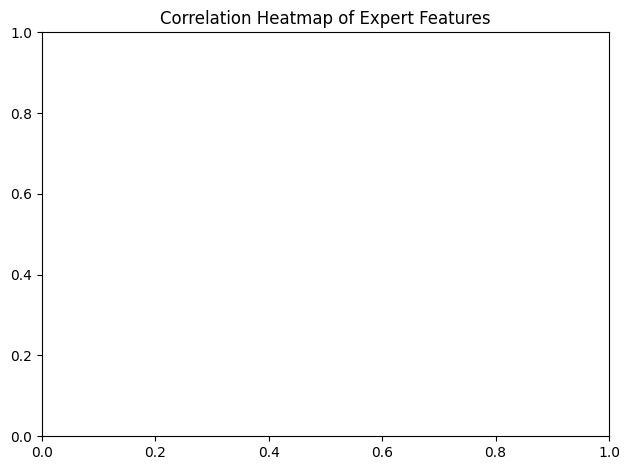

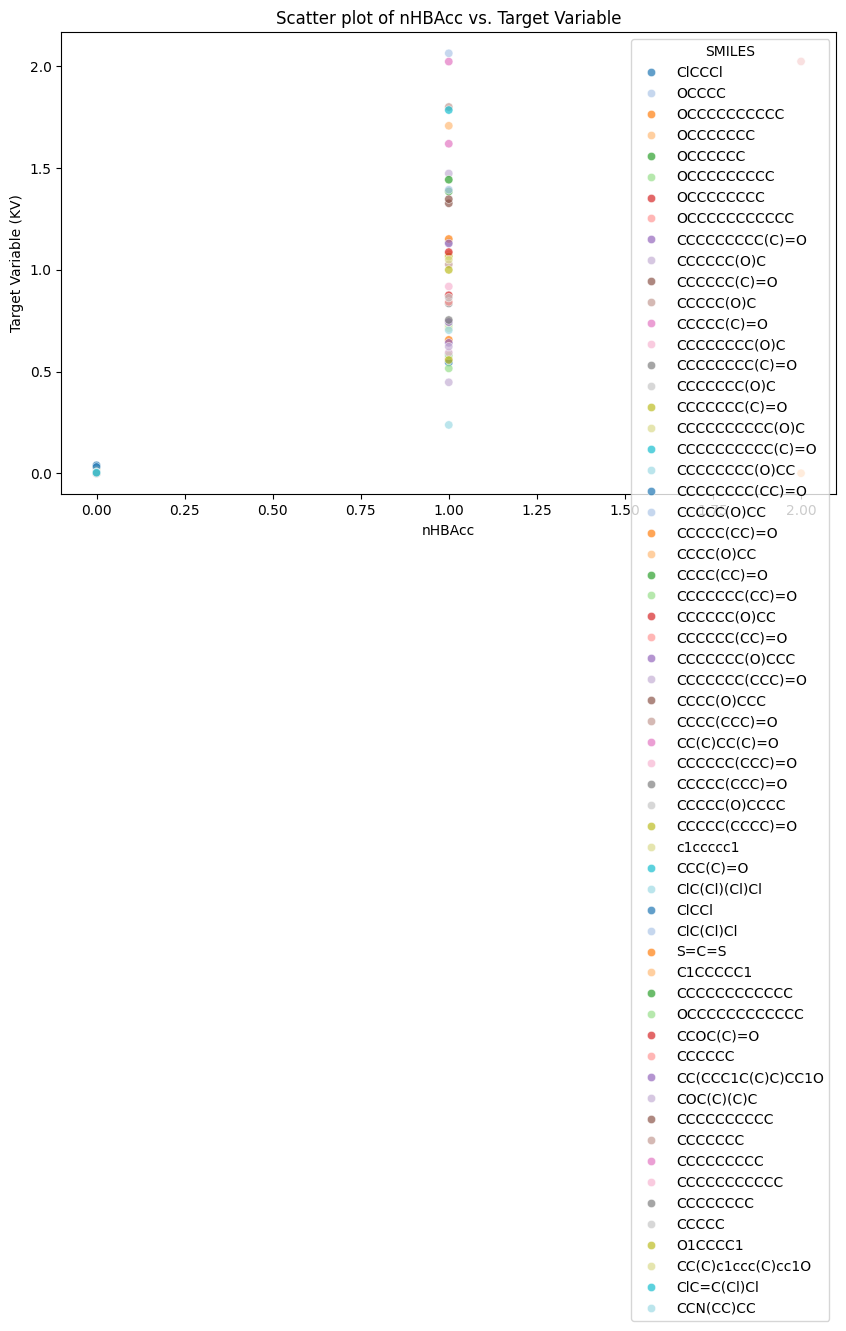

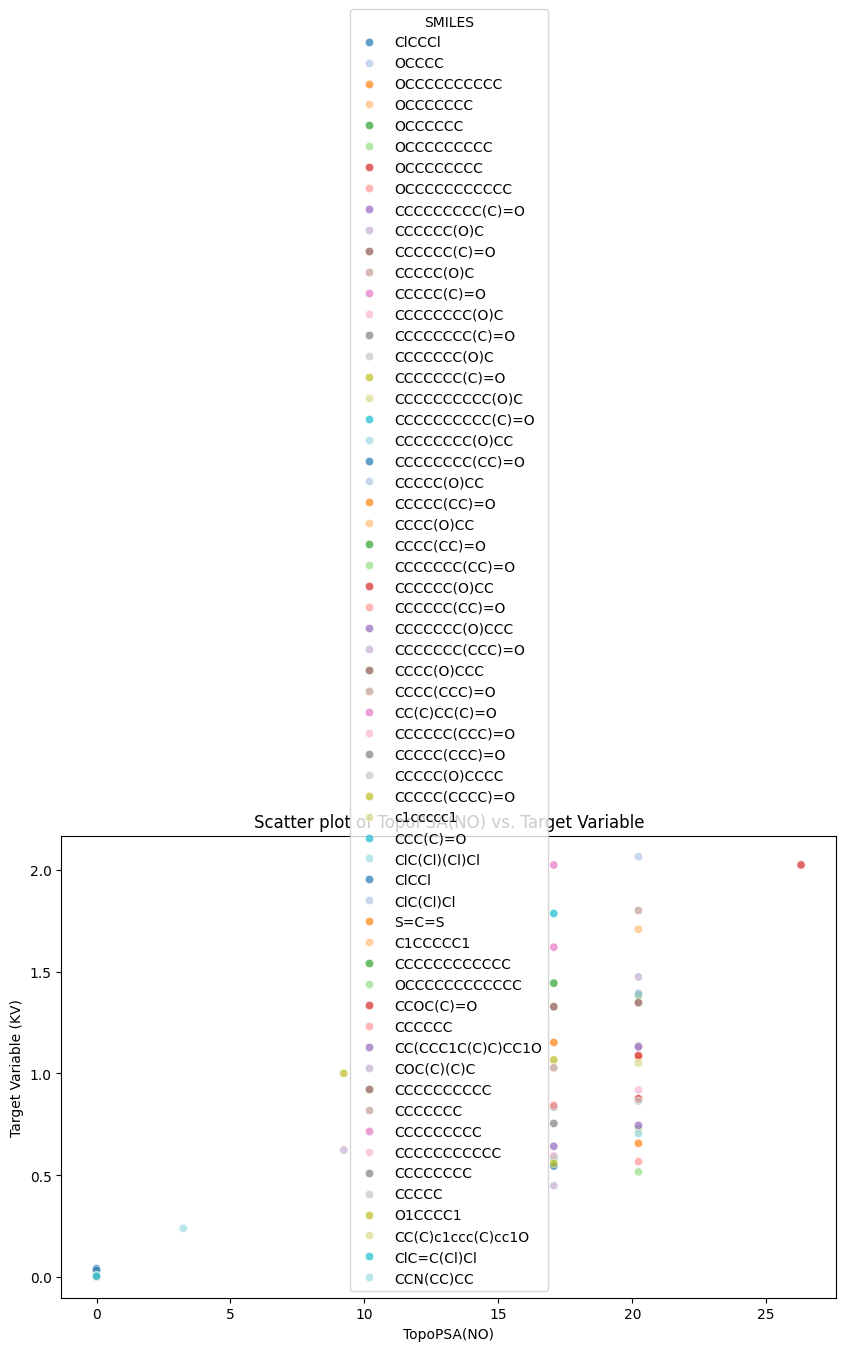

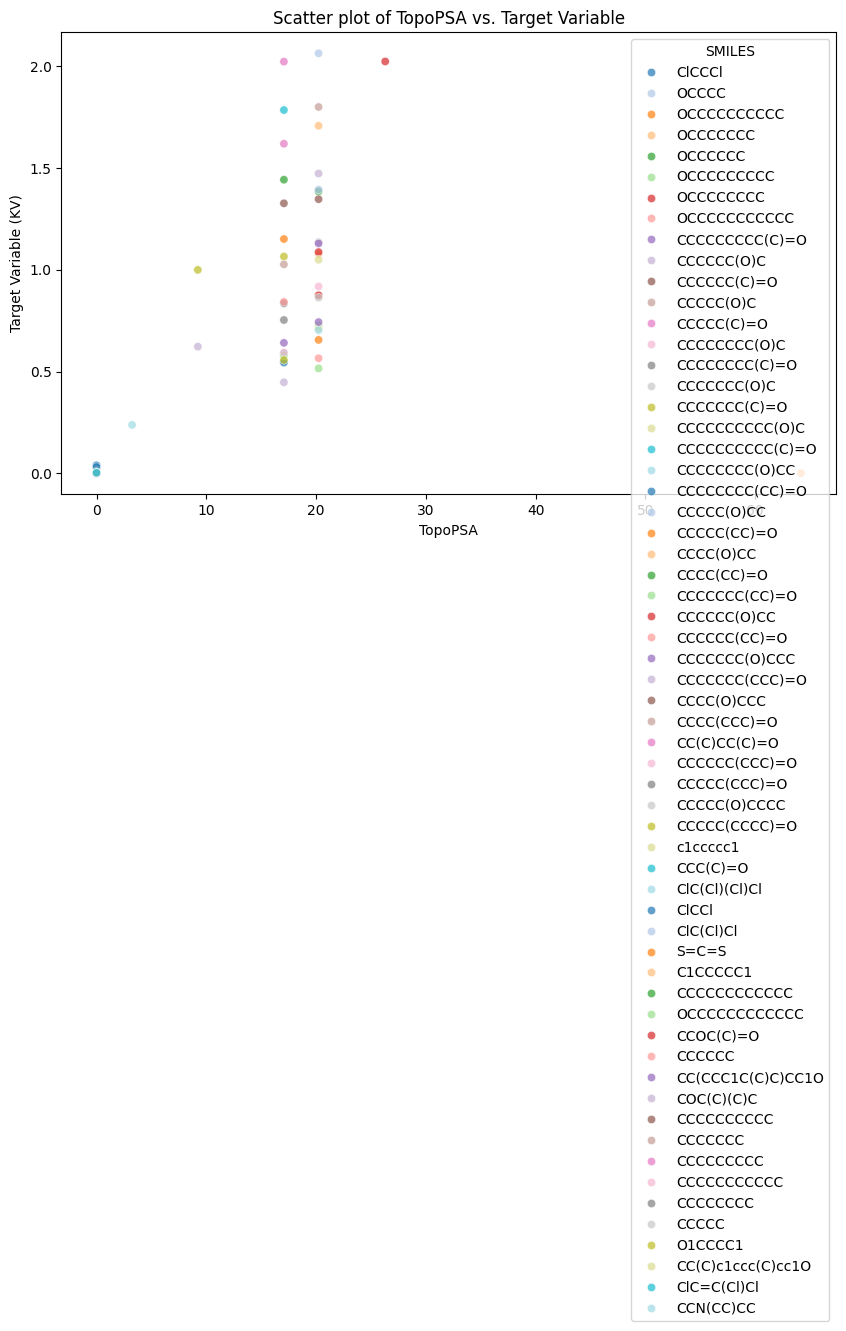

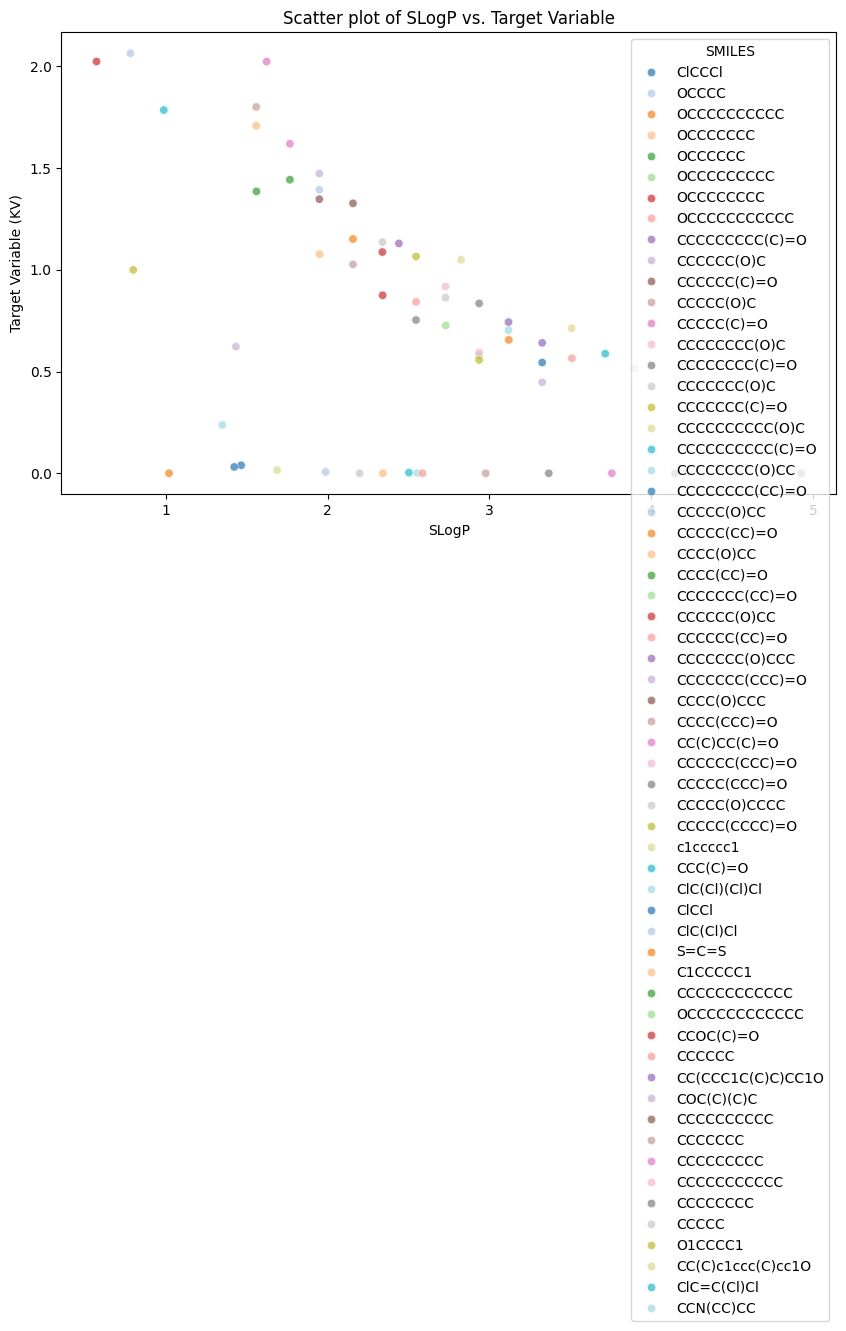

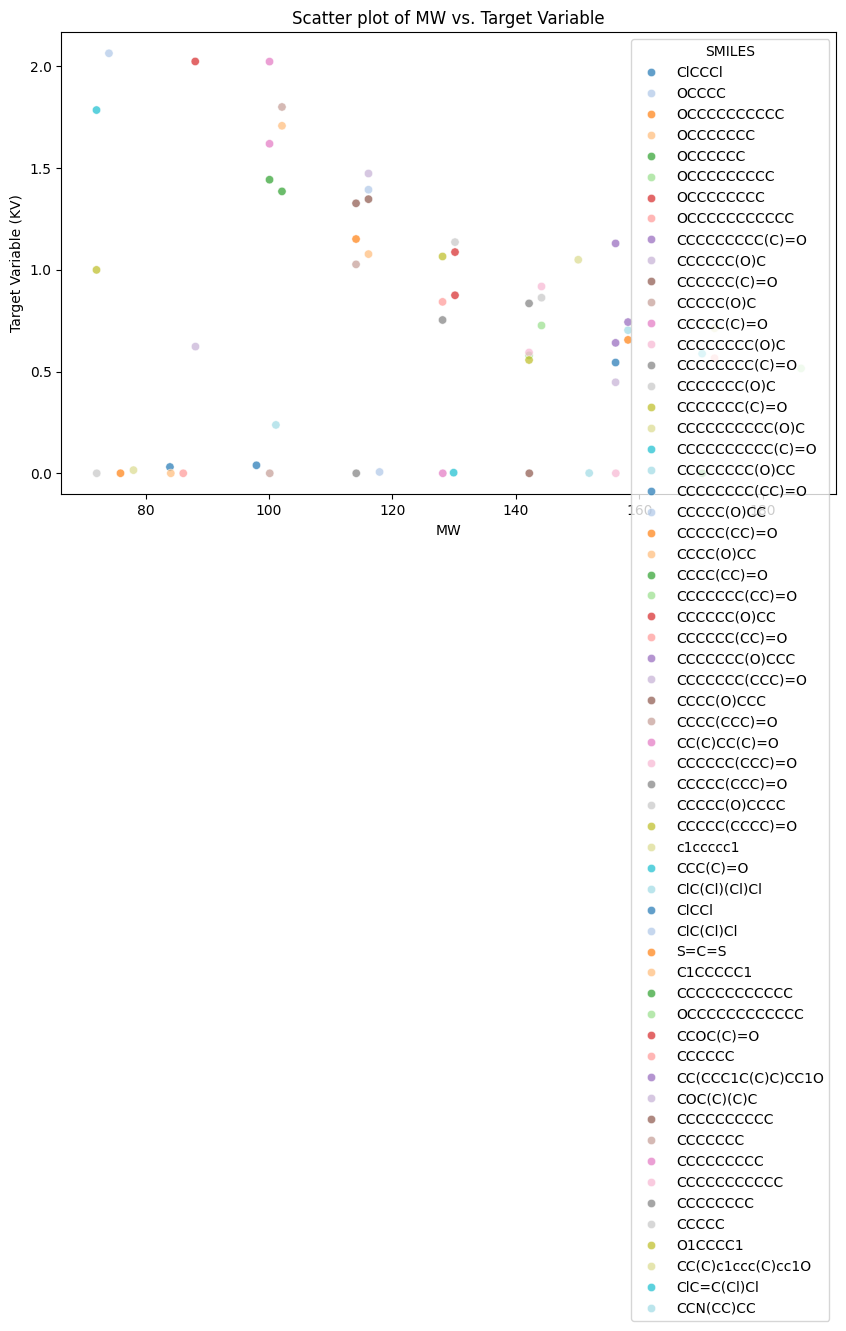

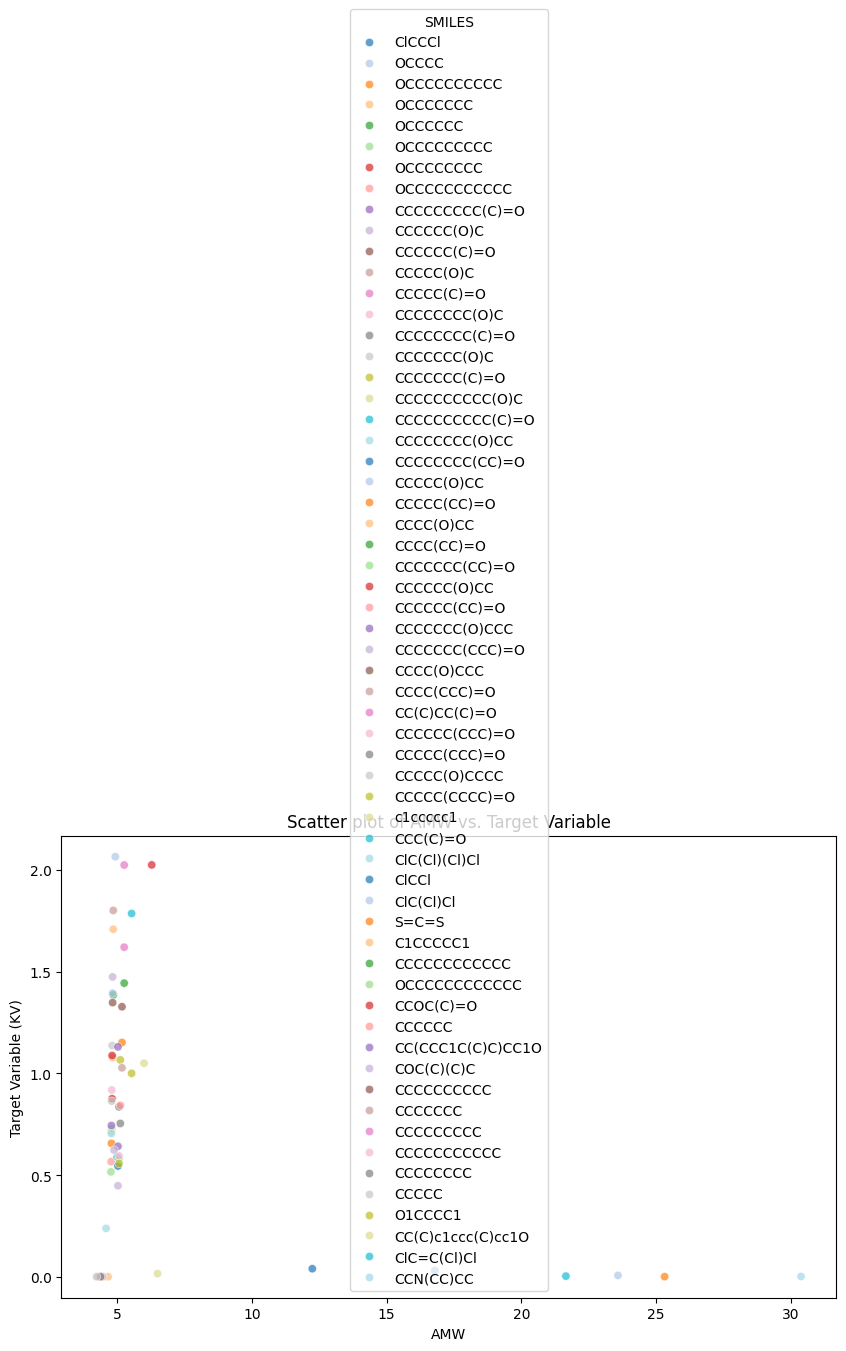

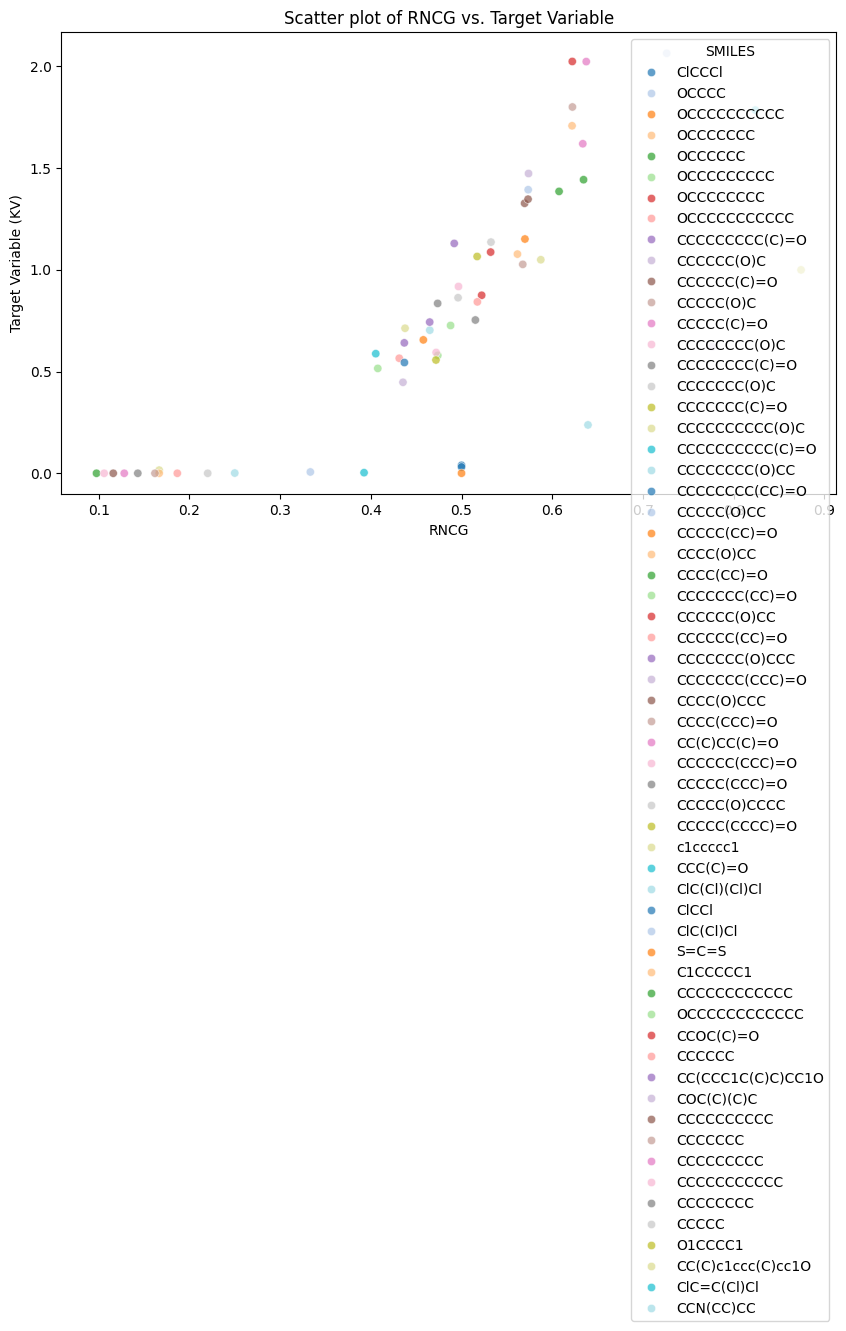

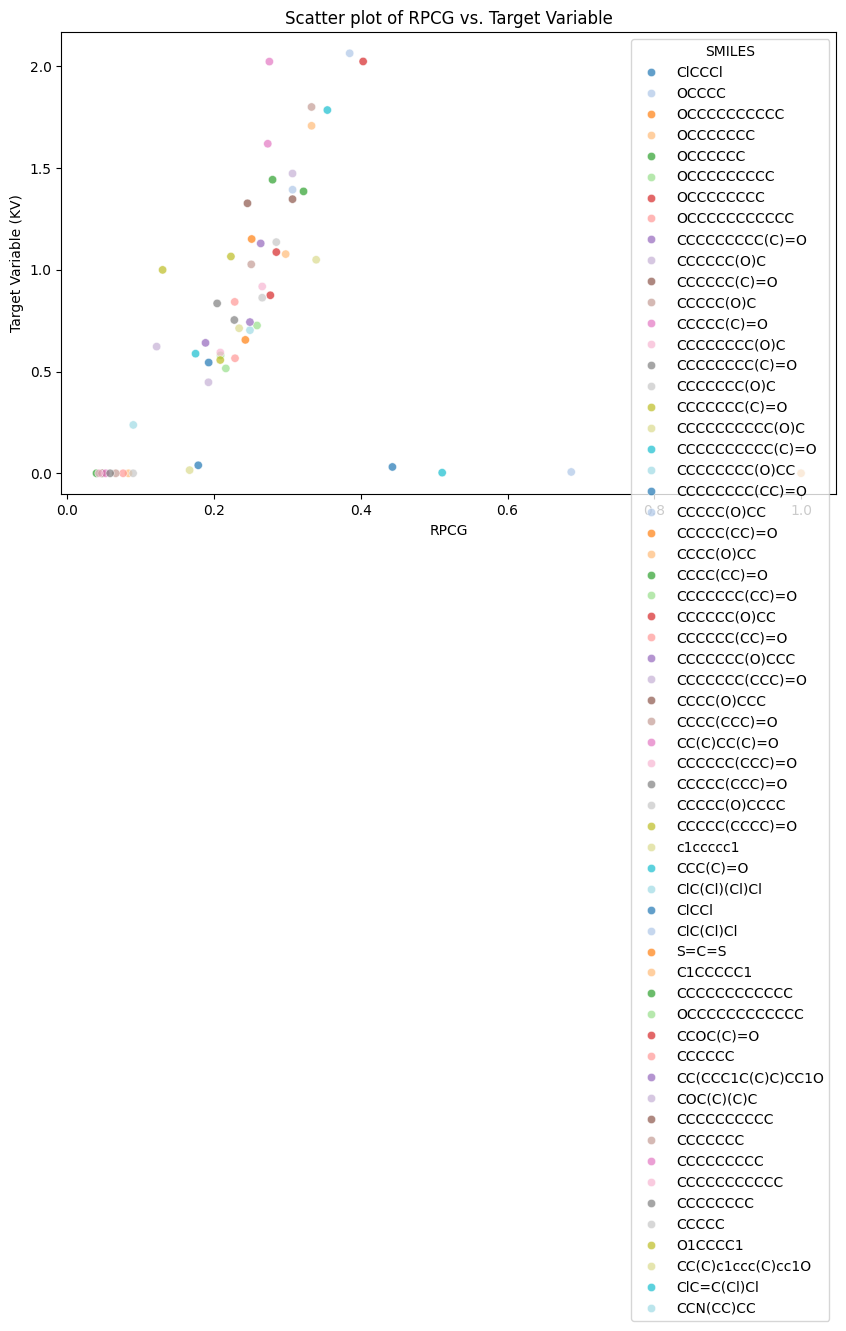

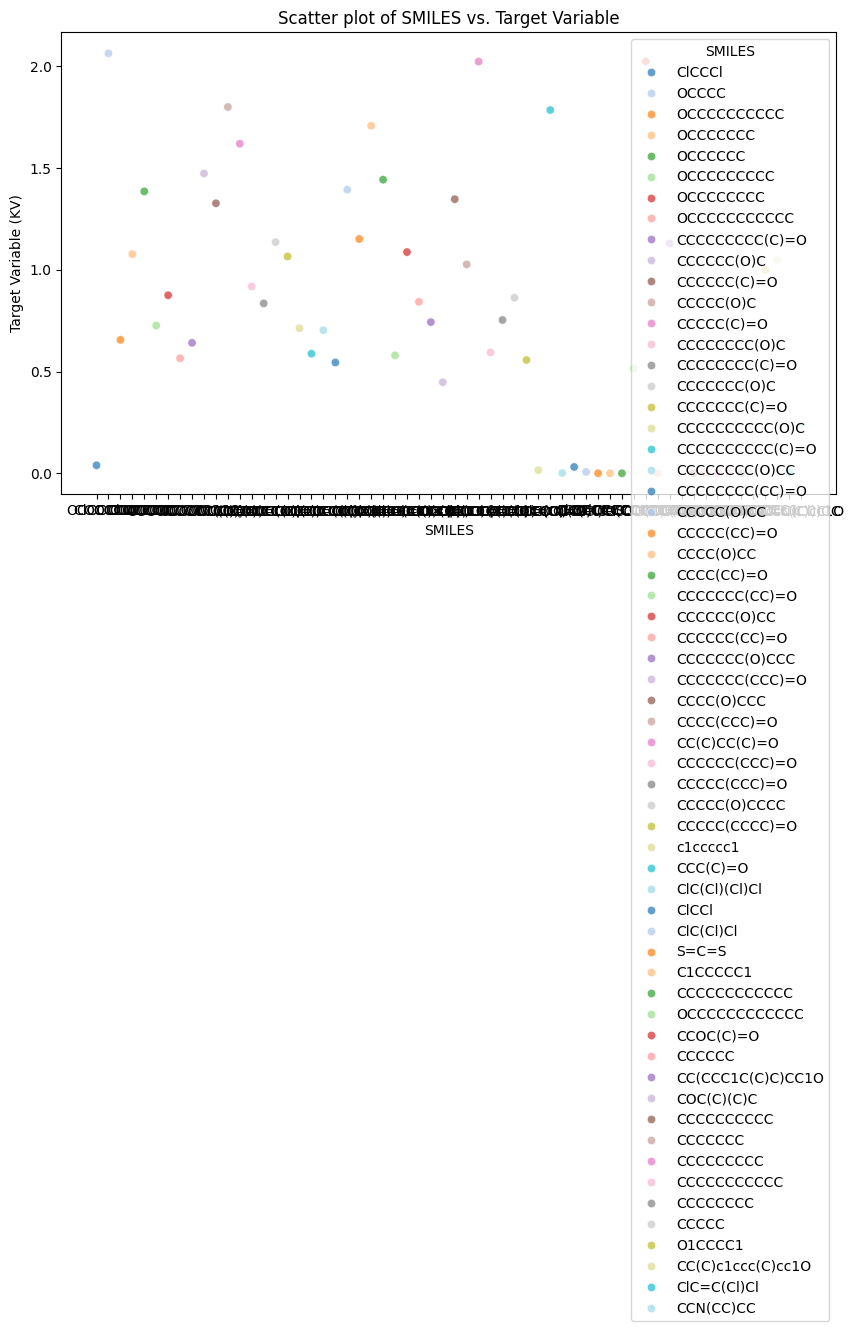

In [50]:

# sns.heatmap(df_expert.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of Expert Features")
plt.tight_layout()

for feat in df_expert.columns:
    if feat != "y":
        plt.figure(figsize=(10, 6))
        #color "SMILES"
        sns.scatterplot(x=df_expert2[feat], y=df_expert2["y"], hue=df_expert2["SMILES"], palette="tab20", alpha=0.7)
        plt.title(f"Scatter plot of {feat} vs. Target Variable")
        plt.xlabel(feat)
        plt.ylabel("Target Variable (KV)")
        plt.show()

In [51]:
import matplotlib.pyplot as plt